In [33]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

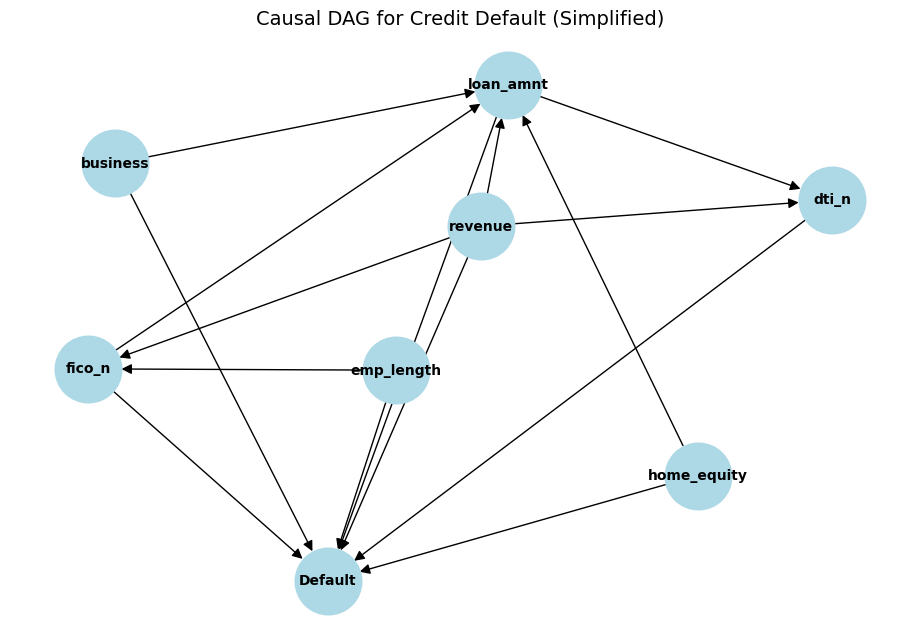

In [34]:


# Define nodes
nodes = ["revenue", "emp_length", "fico_n", "loan_amnt",
         "dti_n", "business", "home_equity", "Default"]

# Create directed graph
G = nx.DiGraph()
G.add_nodes_from(nodes)

# Add edges based on causal reasoning
edges = [
    ("revenue", "fico_n"),
    ("emp_length", "fico_n"),
    ("revenue", "loan_amnt"),
    ("fico_n", "loan_amnt"),
    ("business", "loan_amnt"),
    ("home_equity", "loan_amnt"),
    ("loan_amnt", "dti_n"),
    ("revenue", "dti_n"),
    ("fico_n", "Default"),
    ("dti_n", "Default"),
    ("loan_amnt", "Default"),
    ("revenue", "Default"),
    ("emp_length", "Default"),
    ("home_equity", "Default"),
    ("business", "Default"),
]

G.add_edges_from(edges)

# Draw DAG
plt.figure(figsize=(9, 6))
pos = nx.spring_layout(G, seed=42, k=0.7)
nx.draw(G, pos, with_labels=True, node_color="lightblue",
        node_size=2300, arrowsize=15, font_size=10, font_weight='bold')
plt.title("Causal DAG for Credit Default (Simplified)", fontsize=14)
plt.show()


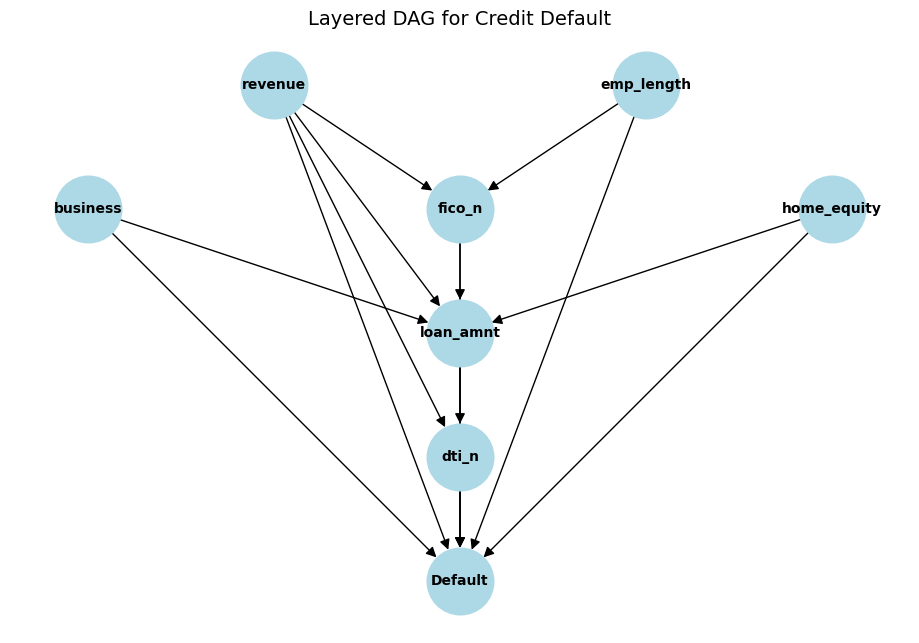

In [35]:
pos = {
    "revenue": (0, 3),
    "emp_length": (2, 3),
    "fico_n": (1, 2),
    "loan_amnt": (1, 1),
    "dti_n": (1, 0),
    "business": (-1, 2),
    "home_equity": (3, 2),
    "Default": (1, -1),
}

plt.figure(figsize=(9, 6))
nx.draw(G, pos, with_labels=True, node_color="lightblue",
        node_size=2300, arrowsize=15, font_size=10, font_weight='bold')
plt.title("Layered DAG for Credit Default", fontsize=14)
plt.show()


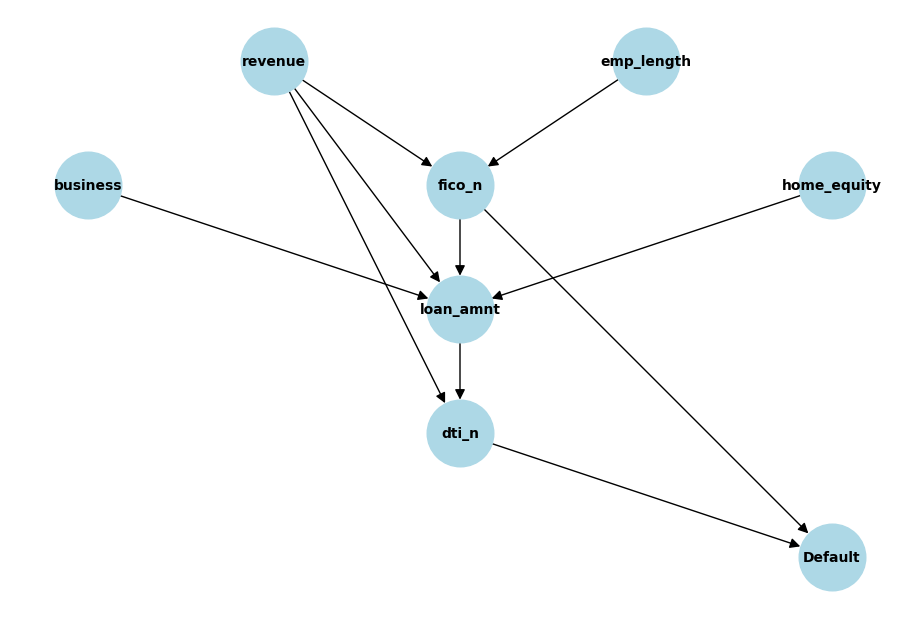

In [55]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
G.add_nodes_from(["revenue","emp_length","fico_n","loan_amnt","dti_n","business","home_equity","Default"])

# Core causal backbone
edges = [
    ("revenue","fico_n"),
    ("emp_length","fico_n"),
    ("revenue","loan_amnt"),
    ("fico_n","loan_amnt"),
    ("business","loan_amnt"),
    ("home_equity","loan_amnt"),
    ("loan_amnt","dti_n"),
    ("revenue","dti_n"),
    ("fico_n","Default"),
    ("dti_n","Default"),
]
G.add_edges_from(edges)

# Draw neatly in layers (no Graphviz needed)
pos = {
    "revenue": (-1, 3), "emp_length": (1, 3),
    "business": (-2, 2), "home_equity": (2, 2),
    "fico_n": (0, 2),
    "loan_amnt": (0, 1),
    "dti_n": (0, 0),
    "Default": (2, -1),
}

plt.figure(figsize=(9, 6))
nx.draw(G, pos, with_labels=True, node_color="lightblue",
        node_size=2300, arrowsize=15, font_size=10, font_weight='bold')
#plt.title("Simplified Causal DAG for Credit Default", fontsize=14)
plt.show()


In [37]:
# =========================
# Core FFNN (supports regression or classification)
# =========================
import torch
import torch.nn as nn
from typing import Iterable, List


class FFNN(nn.Module):
    """
    Flexible Feed-Forward Neural Network.
    Use task='regression' or task='classification'.

    - For regression: linear output, trained with MSELoss.
    - For classification: logit output, trained with BCEWithLogitsLoss.
    """
    def __init__(self, 
                 in_dim: int, 
                 hidden: Iterable[int] = (64, 64), 
                 dropout: float = 0.0, 
                 task: str = "regression"):
        super().__init__()
        assert task in {"regression", "classification"}, "task must be 'regression' or 'classification'"
        self.task = task

        layers: List[nn.Module] = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = h

        # Single scalar output
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)

        # Choose appropriate loss
        self.loss_fn = nn.MSELoss() if task == "regression" else nn.BCEWithLogitsLoss()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass returning logits or raw values."""
        return self.net(x).squeeze(-1)

    @torch.no_grad()
    def predict(
        self,
        X,                       # np.ndarray or torch.Tensor
        device: str = "cpu",
        as_prob: bool = True,
        to_numpy: bool = True,
    ):
        """
        Predict with optional device handling.
        - classification: returns probabilities if as_prob=True (sigmoid), else logits
        - regression: returns raw values
        - to_numpy: return np.ndarray (raveled); if False, returns torch.Tensor
        """
        self.eval()

        # Convert input to tensor on device
        if isinstance(X, np.ndarray):
            x = torch.from_numpy(X.astype(np.float32)).to(device)
        elif isinstance(X, torch.Tensor):
            x = X.to(device)
        else:
            raise TypeError("X must be np.ndarray or torch.Tensor")

        out = self.forward(x)  # shape (N,)
        if self.task == "classification":
            out = torch.sigmoid(out) if as_prob else out  # logits if as_prob=False

        if to_numpy:
            return out.detach().cpu().numpy().ravel()
        return out


In [38]:
# trainer.py
from __future__ import annotations
from dataclasses import dataclass, asdict
from typing import Iterable, List, Optional, Dict, Any, Tuple
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset




# ---------------- Config ----------------
@dataclass
class TrainCfg:
    lr: float = 1e-3
    batch_size: int = 256
    max_epochs: int = 200
    patience: int = 20
    weight_decay: float = 0.0
    device: str = "cpu"
    num_workers: int = 0
    grad_clip: Optional[float] = None  # e.g., 1.0


# ---------------- Mechanism class (no scaling; NumPy IO) ----------------
class Mechanism:
    """
    A trainable causal mechanism for one node in an SCM.

    Supports regression or classification tasks.
    Data is assumed to be pre-scaled NumPy arrays.

    Methods
    --------
    fit(X_train, y_train, X_val=None, y_val=None)
        Train the mechanism.
    predict(X, as_prob=True)
        Predict outputs (probabilities for classification).
    save(path)
        Save model checkpoint.
    load(path, in_dim)
        Restore model and config.
    """
    def __init__(
        self,
        task: str = "regression",
        hidden: Iterable[int] = (64, 64),
        dropout: float = 0.0,
        cfg: TrainCfg = TrainCfg(),
        model: Optional[FFNN] = None,
    ):
        assert task in {"regression", "classification"}
        self.task = task
        self.hidden = tuple(hidden)
        self.dropout = dropout
        self.cfg = cfg
        self.model = model
        self.history: Dict[str, Any] = {}

    # (keep the rest of your Trainer implementation unchanged)

    @staticmethod
    def _make_loader(X: np.ndarray, y: Optional[np.ndarray], batch_size: int, shuffle: bool, num_workers: int) -> DataLoader:
        X_t = torch.from_numpy(X.astype(np.float32))
        if y is not None:
            y_t = torch.from_numpy(y.astype(np.float32)).reshape(-1)
            ds = TensorDataset(X_t, y_t)
        else:
            ds = TensorDataset(X_t)
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers, pin_memory=True)

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: Optional[np.ndarray] = None,
        y_val: Optional[np.ndarray] = None,
    ) -> Tuple[FFNN, Dict[str, Any]]:
        assert X_train.ndim == 2 and y_train.ndim in (1, 2)
        if self.model is None:
            self.model = FFNN(in_dim=X_train.shape[1], hidden=self.hidden, dropout=self.dropout, task=self.task)
        model = self.model.to(self.cfg.device)

        train_loader = self._make_loader(X_train, y_train, self.cfg.batch_size, True, self.cfg.num_workers)
        val_loader = self._make_loader(X_val, y_val, self.cfg.batch_size, False, self.cfg.num_workers) if X_val is not None else None

        criterion = nn.BCEWithLogitsLoss() if self.task == "classification" else nn.MSELoss()
        optim = torch.optim.Adam(model.parameters(), lr=self.cfg.lr, weight_decay=self.cfg.weight_decay)

        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_val = float("inf")
        best_epoch = -1
        no_improve = 0
        history = {"train_loss": [], "val_loss": [], "cfg": asdict(self.cfg), "task": self.task, "hidden": self.hidden, "dropout": self.dropout}

        for epoch in range(self.cfg.max_epochs):
            # ---- train ----
            model.train()
            total, n = 0.0, 0
            for xb, yb in train_loader:
                xb, yb = xb.to(self.cfg.device), yb.to(self.cfg.device)
                optim.zero_grad(set_to_none=True)
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                if self.cfg.grad_clip:
                    nn.utils.clip_grad_norm_(model.parameters(), self.cfg.grad_clip)
                optim.step()
                total += loss.item() * xb.size(0)
                n += xb.size(0)
            train_loss = total / max(n, 1)
            history["train_loss"].append(train_loss)

            # ---- validate ----
            if val_loader is not None:
                model.eval()
                vtotal, vn = 0.0, 0
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb, yb = xb.to(self.cfg.device), yb.to(self.cfg.device)
                        vloss = criterion(model(xb), yb)
                        vtotal += vloss.item() * xb.size(0)
                        vn += xb.size(0)
                val_loss = vtotal / max(vn, 1)
            else:
                val_loss = train_loss
            history["val_loss"].append(val_loss)

            # ---- early stopping ----
            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_epoch = epoch
                no_improve = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= self.cfg.patience:
                    break

        model.load_state_dict({k: v.to(self.cfg.device) for k, v in best_state.items()})
        history["best_val"] = best_val
        history["best_epoch"] = best_epoch
        self.history = history
        return model, history

    @torch.no_grad()
    def predict(self, X: np.ndarray, as_prob: bool = True) -> np.ndarray:
        assert self.model is not None, "Call fit() first or pass a pre-trained model."
        return self.model.predict(X, device=self.cfg.device, as_prob=as_prob)

    def save(self, path: str) -> None:
        assert self.model is not None, "Nothing to save; fit a model first."
        torch.save({
            "state_dict": self.model.state_dict(),
            "task": self.task,
            "hidden": self.hidden,
            "dropout": self.dropout,
            "cfg": asdict(self.cfg),
            "history": self.history,
        }, path)

    @staticmethod
    def load(path: str, in_dim: int) -> "Mechanism":
        ckpt = torch.load(path, map_location="cpu")
        mechanism = Mechanism(task=ckpt["task"], hidden=tuple(ckpt["hidden"]), dropout=ckpt["dropout"], cfg=TrainCfg(**ckpt["cfg"]))
        mechanism.model = FFNN(in_dim=in_dim, hidden=mechanism.hidden, dropout=mechanism.dropout, task=mechanism.task)
        mechanism.model.load_state_dict(ckpt["state_dict"])
        mechanism.history = ckpt.get("history", {})
        return mechanism


In [39]:
# scm.py
from __future__ import annotations
from typing import Dict, List, Optional, Tuple, Any




class SCM:
    """
    SCM orchestrator for NumPy arrays (already encoded/scaled).
    - Uses a DAG (networkx.DiGraph)
    - `idx` maps each node -> column index in X
    - Trains a Mechanism for each endogenous node using y_per_node[node]
    - forward(X): returns a dict of node -> array (recomputed or observed)
    - do(X, intervention): overrides nodes and recomputes descendants
    """

    def __init__(
        self,
        G: nx.DiGraph,
        node_tasks: Dict[str, str],  # e.g. {"fico_n":"regression","dti_n":"regression","Default":"classification"}
        idx: Dict[str, int],         # node -> column index in X
        cfg: Optional["TrainCfg"] = None,
        hidden: Tuple[int, ...] = (64, 64),
        dropout: float = 0.0,
        mechanism_cls = None,        # pass your Mechanism class if imported differently
    ):
        assert nx.is_directed_acyclic_graph(G), "Graph must be a DAG"
        self.G = G
        self.node_tasks = node_tasks
        self.idx = idx
        self.cfg = cfg or TrainCfg()
        self.hidden = hidden
        self.dropout = dropout
        self.Mechanism = mechanism_cls or Mechanism

        # build mechanisms for endogenous nodes only
        self.mechanisms: Dict[str, Mechanism] = {}
        for v in self.G.nodes:
            if self.G.in_degree(v) > 0:
                task = self.node_tasks.get(v, "regression")
                self.mechanisms[v] = self.Mechanism(task=task, hidden=self.hidden, dropout=self.dropout, cfg=self.cfg)

    @property
    def topo(self) -> List[str]:
        return list(nx.topological_sort(self.G))

    def parents(self, node: str) -> List[str]:
        return list(self.G.predecessors(node))

    # ---------- training ----------
    def fit_from_arrays(
        self,
        X: np.ndarray,
        y_per_node: Dict[str, np.ndarray],
        val_frac: float = 0.1,
        seed: int = 42,
    ) -> None:
        """
        Train each endogenous node on (parents -> node_target).
        y_per_node should contain targets for each endogenous node (including 'Default').
        For intermediate nodes, you can set y_per_node[v] = X[:, idx[v]] to learn the mechanism.
        """
        rng = np.random.RandomState(seed)
        n = X.shape[0]
        idx_all = np.arange(n)

        for v in self.topo:
            if v not in self.mechanisms:
                continue  # root
            parents = self.parents(v)
            Xv = np.column_stack([X[:, self.idx[p]] for p in parents])
            yv = y_per_node[v].reshape(-1)

            rng.shuffle(idx_all)
            k = int(n * (1 - val_frac))
            tr, va = idx_all[:k], idx_all[k:] if val_frac > 0 else (idx_all, idx_all[:0])

            self.mechanisms[v].fit(Xv[tr], yv[tr], Xv[va] if val_frac > 0 else None, yv[va] if val_frac > 0 else None)

    # ---------- inference ----------
    def forward(
        self,
        X: np.ndarray,
        recompute: Optional[List[str]] = None,
        return_matrix: bool = False,
    ) -> Dict[str, np.ndarray] | Tuple[Dict[str, np.ndarray], np.ndarray]:
        """
        Compute all nodes in topological order.
        By default we **keep observed columns from X** for nodes that exist in idx.
        If `recompute` contains a node name, we recompute that node (and you likely want to add descendants via `do()`).
        """
        n = X.shape[0]
        values: Dict[str, np.ndarray] = {}

        # start from observed values present in X
        for v, j in self.idx.items():
            values[v] = X[:, j].copy()

        recompute_set = set(recompute or [])

        # topological pass
        for v in self.topo:
            if v in recompute_set or (v not in values and v in self.mechanisms):
                parents = self.parents(v)
                Pv = np.column_stack([values[p] for p in parents])  # parents already available
                as_prob = (self.node_tasks.get(v, "regression") == "classification")
                values[v] = self.mechanisms[v].predict(Pv, as_prob=as_prob)

        if return_matrix:
            # build a matrix aligned to idx order
            V = np.zeros((n, len(self.idx)), dtype=np.float32)
            for v, j in self.idx.items():
                V[:, j] = values[v]
            return values, V
        return values

    # ---------- intervention ----------
    def do(
        self,
        X: np.ndarray,
        intervention: Dict[str, Any],   # node -> scalar or vector
        return_matrix: bool = False,
    ) -> Dict[str, np.ndarray] | Tuple[Dict[str, np.ndarray], np.ndarray]:
        """
        Pearl's do(): override target nodes, then recompute all descendants.
        We start from X (observed), set intervened nodes, then recompute descendants in topo order.
        """
        n = X.shape[0]
        # initialize values from observed X
        values: Dict[str, np.ndarray] = {v: X[:, j].copy() for v, j in self.idx.items()}

        # apply interventions
        for k, v in intervention.items():
            if np.isscalar(v):
                values[k] = np.full(n, float(v), dtype=np.float32)
            else:
                vv = np.asarray(v).reshape(-1)
                if len(vv) != n:
                    raise ValueError(f"Intervention '{k}' length {len(vv)} != n={n}")
                values[k] = vv.astype(np.float32)

        # descendants to update
        to_update: set[str] = set()
        for k in intervention:
            to_update |= nx.descendants(self.G, k)

        # recompute descendants in topo order
        for v in self.topo:
            if v in intervention:
                continue
            if v in to_update and v in self.mechanisms:
                parents = self.parents(v)
                Pv = np.column_stack([values[p] for p in parents])
                as_prob = (self.node_tasks.get(v, "regression") == "classification")
                values[v] = self.mechanisms[v].predict(Pv, as_prob=as_prob)

        if return_matrix:
            V = np.zeros((n, len(self.idx)), dtype=np.float32)
            for v, j in self.idx.items():
                V[:, j] = values[v]
            return values, V
        return values


In [40]:
import numpy as np
import networkx as nx
# from scm_arrays import SCMArrays
# from mechanism import Mechanism, TrainCfg

# 1. Define DAG (same as before)
def build_credit_dag() -> nx.DiGraph:
    G = nx.DiGraph()
    G.add_nodes_from([
        "revenue", "emp_length", "fico_n",
        "loan_amnt", "dti_n", "business",
        "home_equity", "Default"
    ])
    G.add_edges_from([
        ("revenue", "fico_n"),
        ("emp_length", "fico_n"),
        ("revenue", "loan_amnt"),
        ("fico_n", "loan_amnt"),
        ("business", "loan_amnt"),
        ("home_equity", "loan_amnt"),
        ("loan_amnt", "dti_n"),
        ("revenue", "dti_n"),
        ("fico_n", "Default"),
        ("dti_n", "Default"),
    ])
    return G

# 2. Load data

X_train = np.load("data/X_train.npy")
X_test = np.load("data/X_test.npy")
y_default_train = np.load("data/y_train.npy")
y_default_test = np.load("data/y_test.npy")

# 3. Column index map (aligned to X)
idx = {
    "revenue": 0,
    "dti_n": 1,
    "loan_amnt": 2,
    "fico_n": 3,
    "emp_length": 4,
    "business": 5,
    "home_equity": 6,
}

# 4. Node tasks
node_tasks = {
    "fico_n": "regression",
    "loan_amnt": "regression",
    "dti_n": "regression",
    "Default": "classification",
}

# 5. Targets per endogenous node
# intermediate nodes use observed columns as their y target
y_per_node = {
    "fico_n":    X_train[:, idx["fico_n"]],
    "loan_amnt": X_train[:, idx["loan_amnt"]],
    "dti_n":     X_train[:, idx["dti_n"]],
    "Default":   y_default_train,
}

# 6) FAST training config
use_device = "cuda" if torch.cuda.is_available() else "cpu"
cfg_fast = TrainCfg(
    lr=3e-3,           # slightly higher LR for speed
    batch_size=1024,   # larger batch for throughput
    max_epochs=50,     # fewer epochs
    patience=5,        # aggressive early stopping
    weight_decay=1e-5,
    device=use_device,
    num_workers=0
)

G = build_credit_dag()
scm = SCM(
    G=G,
    node_tasks=node_tasks,
    idx=idx,
    cfg=cfg_fast,
    hidden=(16, 8),    # smaller nets for speed
    dropout=0.0
)

# ---- Train
scm.fit_from_arrays(X_train, y_per_node, val_frac=0.2, seed=42)




c:\Users\JanderM\AppData\Local\anaconda3\envs\xai-project\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


AUC: 0.6226, PR AUC: 0.2730, F1@0.5: 0.3586
Best F1: 0.3609 at threshold: 0.487


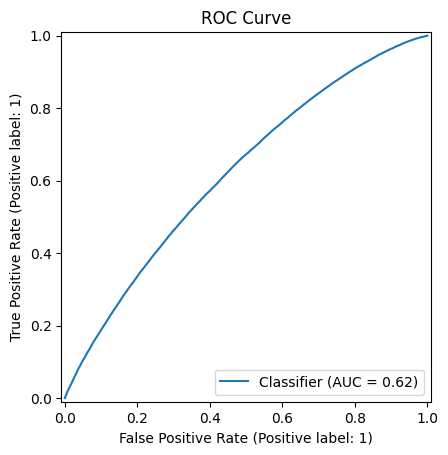

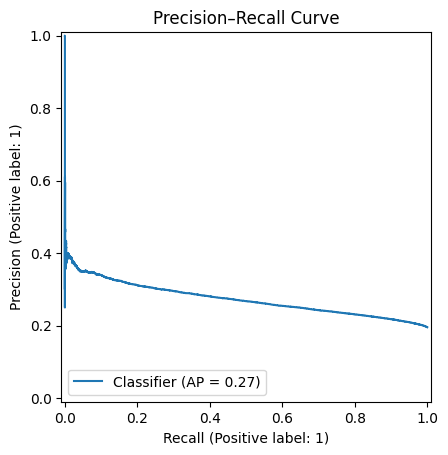

✅ Results saved to results\eval_20251014_150637.json
Factual (no intervention) results: {'timestamp': '2025-10-14T15:06:37', 'auc': 0.6225987428968964, 'pr_auc': 0.2729780427723339, 'f1@0.5': 0.35859649534492166, 'best_f1': 0.360932001485911, 'best_threshold': 0.48719459772109985, 'y_pred': array([0, 0, 0, ..., 0, 1, 0], shape=(253899,))}


In [41]:
# ---- Inference (factual): use observed intermediates (fico, dti) from X_test
values = scm.forward(X_test)
p_default = values["Default"]

from utils import evaluate_predictions

results_factual = evaluate_predictions(y_default_test, p_default)
print("Factual (no intervention) results:", results_factual)

In [42]:
import numpy as np

def check_nans(X, idx):
    for k, j in idx.items():
        n = np.isnan(X[:, j]).sum()
        if n:
            print(f"NaNs in X column '{k}': {n}")

print("=== NaNs in X_train ===")
check_nans(X_train, idx)
print("=== NaNs in X_test ===")
check_nans(X_test, idx)


=== NaNs in X_train ===
=== NaNs in X_test ===


[0.43343997 0.5113956  0.4421722  ... 0.39763176 0.45601442 0.5205981 ]
NaN count in p_default_from_roots: 0 out of 253899
AUC: 0.5392, PR AUC: 0.2129, F1@0.5: 0.3089
Best F1: 0.3290 at threshold: 0.454


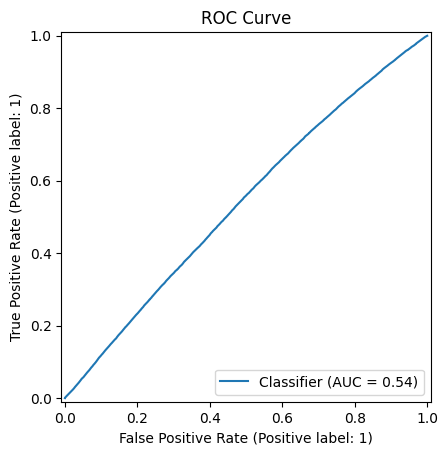

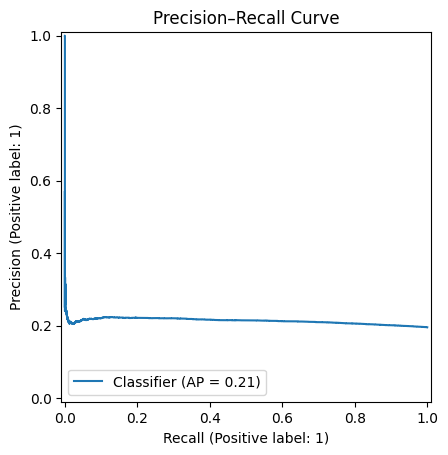

✅ Results saved to results\eval_20251014_150637.json
Causal forward from roots results: {'timestamp': '2025-10-14T15:06:37', 'auc': 0.539151214999443, 'pr_auc': 0.21286424928830994, 'f1@0.5': 0.3089054684662028, 'best_f1': 0.3289534523871577, 'best_threshold': 0.45407721400260925, 'y_pred': array([0, 1, 0, ..., 0, 0, 1], shape=(253899,))}


In [43]:
# ---- Inference (causal forward from roots): recompute intermediates + Default
values_from_roots = scm.forward(X_test, recompute=["fico_n", "loan_amnt", "dti_n", "Default"])
p_default_from_roots = values_from_roots["Default"]
print(p_default_from_roots)

# count NaNs in p_default_from_roots
nan_count = np.isnan(p_default_from_roots).sum()
print(f"NaN count in p_default_from_roots: {nan_count} out of {len(p_default_from_roots)}")

results_from_roots = evaluate_predictions(y_default_test, p_default_from_roots)
print("Causal forward from roots results:", results_from_roots)

In [ ]:
import numpy as np

# Pick a single borrower from test set
i = 10   # sample index (choose any)
x_i = X_test[i:i+1]  # keep 2D shape (1, n_features)
y_true = y_default_test[i]

# --- Factual prediction (no intervention)
values_fact = scm.forward(x_i)
p_fact = float(values_fact["Default"])
revenue_fact = float(x_i[:, idx["revenue"]])

print(f"Sample {i}:")
print(f"  True Default Label: {y_true}")
print(f"  Observed income (scaled): {revenue_fact:.3f}")
print(f"  Predicted P(Default): {p_fact:.4f}")

# --- Causal intervention: increase income by +0.2 std (in scaled space)
revenue_mean = X_train[:, idx["revenue"]].mean()
revenue_std  = X_train[:, idx["revenue"]].std()
new_revenue  = revenue_fact + .2 * revenue_std  # +0.2 std increase

do_result = scm.do(x_i, {"revenue": new_revenue})
p_do = float(do_result["Default"])

print("\n[Do-intervention] Increased income:")
print(f"  New income (scaled): {new_revenue:.3f}")
print(f"  New predicted P(Default): {p_do:.4f}")
print(f"  Δ change in default probability: {p_do - p_fact:+.4f}")


Sample 10:
  True Default Label: 1
  Observed income (scaled): 0.113
  Predicted P(Default): 0.5540

[Do-intervention] Increased income:
  New income (scaled): 0.313
  New predicted P(Default): 0.4711
  Δ change in default probability: -0.0830


C:\Users\JanderM\AppData\Local\Temp\ipykernel_39456\2779266765.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_fact = float(values_fact["Default"])
C:\Users\JanderM\AppData\Local\Temp\ipykernel_39456\2779266765.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  revenue_fact = float(x_i[:, idx["revenue"]])
C:\Users\JanderM\AppData\Local\Temp\ipykernel_39456\2779266765.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_do = float(do_result["Default"])


In [45]:
# --- Factual prediction (no intervention)
values_fact = scm.forward(x_i)
p_fact = float(values_fact["Default"])
loan_fact = float(x_i[:, idx["loan_amnt"]])

print(f"Sample {i}:")
print(f"  True Default Label: {y_true}")
print(f"  Observed loan_amnt (scaled): {loan_fact:.3f}")
print(f"  Predicted P(Default): {p_fact:.4f}")

# --- Causal intervention: increase loan amount by +0.2 std (in *scaled* space)
loan_mean = X_train[:, idx["loan_amnt"]].mean()
loan_std  = X_train[:, idx["loan_amnt"]].std()
new_loan  = loan_fact + 0.2 * loan_std

do_result = scm.do(x_i, {"loan_amnt": new_loan})
p_do = float(do_result["Default"])

print("\n[Do-intervention] Increased loan amount:")
print(f"  New loan_amnt (scaled): {new_loan:.3f}")
print(f"  New predicted P(Default): {p_do:.4f}")
print(f"  Δ change in default probability: {p_do - p_fact:+.4f}")

Sample 10:
  True Default Label: 1
  Observed loan_amnt (scaled): 0.562
  Predicted P(Default): 0.5540

[Do-intervention] Increased loan amount:
  New loan_amnt (scaled): 0.762
  New predicted P(Default): 0.6032
  Δ change in default probability: +0.0492


C:\Users\JanderM\AppData\Local\Temp\ipykernel_39456\2549554322.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_fact = float(values_fact["Default"])
C:\Users\JanderM\AppData\Local\Temp\ipykernel_39456\2549554322.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loan_fact = float(x_i[:, idx["loan_amnt"]])
C:\Users\JanderM\AppData\Local\Temp\ipykernel_39456\2549554322.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_do = float(do_result["Default"])


In [53]:
X_train[:, idx["home_equity"]]

array([ 0.86051884,  0.86051884,  0.86051884, ...,  0.86051884,
        0.86051884, -1.1620896 ], shape=(397076,))

In [51]:
# --- Factual prediction (no intervention)
values_fact = scm.forward(x_i)
p_fact = float(values_fact["Default"])
he_fact = x_i[:, idx["home_equity"]][0]

print(f"Sample {i}:")
print(f"  True Default Label: {y_true}")
print(f"  Observed home_equity: {he_fact}  (-1.1620896 = no equity, 0.86051884 = has equity)")
print(f"  Predicted P(Default): {p_fact:.4f}")

# --- Causal intervention: toggle home_equity (0<->1)
new_he = 0.86051884 if he_fact < 0 else -1.1620896 # scaled binary values
x_he = scm.do(x_i, {"home_equity": new_he})
p_do = float(x_he["Default"])

print("\n[Do-intervention] Toggle home_equity:")
print(f"  New home_equity: {new_he}")
print(f"  New predicted P(Default): {p_do:.4f}")
print(f"  Δ change in default probability: {p_do - p_fact:+.4f}")


Sample 10:
  True Default Label: 1
  Observed home_equity: 0.8605188434514266  (-1.1620896 = no equity, 0.86051884 = has equity)
  Predicted P(Default): 0.5540

[Do-intervention] Toggle home_equity:
  New home_equity: -1.1620896
  New predicted P(Default): 0.5942
  Δ change in default probability: +0.0402


C:\Users\JanderM\AppData\Local\Temp\ipykernel_39456\2324712813.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_fact = float(values_fact["Default"])
C:\Users\JanderM\AppData\Local\Temp\ipykernel_39456\2324712813.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_do = float(x_he["Default"])


In [ ]:
vals_before = scm.forward(x_i)
vals_after  = scm.do(x_i, {"home_equity": -1.1620896})

print("loan_amnt  before/after:", float(vals_before["loan_amnt"]), float(vals_after["loan_amnt"]))
print("dti_n      before/after:", float(vals_before["dti_n"]),     float(vals_after["dti_n"]))
print("P(Default) before/after:", float(vals_before["Default"]),   float(vals_after["Default"]))


loan_amnt  before/after: 0.5617553557654683 0.0693599134683609
dti_n      before/after: -0.6263803180754589 -0.08305463194847107
P(Default) before/after: 0.5540101528167725 0.5941823720932007


C:\Users\JanderM\AppData\Local\Temp\ipykernel_39456\1452995649.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("loan_amnt  before/after:", float(vals_before["loan_amnt"]), float(vals_after["loan_amnt"]))
C:\Users\JanderM\AppData\Local\Temp\ipykernel_39456\1452995649.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("dti_n      before/after:", float(vals_before["dti_n"]),     float(vals_after["dti_n"]))
C:\Users\JanderM\AppData\Local\Temp\ipykernel_39456\1452995649.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from yo